***Introduction***

The dataset includes demographic, biometric, and lifestyle information for individuals, aimed at understanding cardiovascular health. Variables include sex, age, weight, height, BMI, abdominal circumference, blood pressure, cholesterol levels, fasting blood sugar, physical activity level, and family history of cardiovascular disease. Additional derived metrics such as waist-to-height ratio, estimated LDL, CVD risk score, and blood pressure category are included.

This data will be analyzed to identify patterns and trends related to cardiovascular risk. .

In [32]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
plt.style.use('ggplot')
import warnings
warnings.filterwarnings("ignore")
from sklearn.impute import SimpleImputer

In [5]:
#Import Data
df = pd.read_csv("C:/Users/Admin/Data Project/Cardiovascular Dataset.csv")
df.head()

,Sex,Age,Weight (kg),Height (m),BMI,Abdominal Circumference (cm),Blood Pressure (mmHg),Total Cholesterol (mg/dL),HDL (mg/dL),Fasting Blood Sugar (mg/dL),...,Physical Activity Level,Family History of CVD,Height (cm),Waist-to-Height Ratio,Systolic BP,Diastolic BP,Blood Pressure Category,Estimated LDL (mg/dL),CVD Risk Score,CVD Risk Level
0,F,32.0,69.1,1.71,23.6,86.2,125/79,248.0,78.0,111.0,...,Low,N,171.0,0.504,125.0,79.0,Elevated,140.0,17.93,INTERMEDIARY
1,F,55.0,118.7,1.69,41.6,82.5,139/70,162.0,50.0,135.0,...,High,Y,169.0,0.488,139.0,70.0,Hypertension Stage 1,82.0,20.51,HIGH
2,M,NaN,NaN,1.83,26.9,106.7,104/77,103.0,73.0,114.0,...,High,Y,183.0,0.583,104.0,77.0,Normal,0.0,12.64,INTERMEDIARY
3,M,44.0,108.3,1.80,33.4,96.6,140/83,134.0,46.0,91.0,...,High,Y,NaN,0.537,140.0,83.0,Hypertension Stage 1,58.0,16.36,INTERMEDIARY
4,F,32.0,99.5,1.86,28.8,102.7,144/83,146.0,64.0,141.0,...,High,N,186.0,0.552,144.0,83.0,Hypertension Stage 1,52.0,17.88,INTERMEDIARY


**Data Cleaning**

In [6]:
# Inormation about the data 
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1529 entries, 0 to 1528
Data columns (total 22 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Sex                           1529 non-null   object 
 1   Age                           1451 non-null   float64
 2   Weight (kg)                   1448 non-null   float64
 3   Height (m)                    1462 non-null   float64
 4   BMI                           1465 non-null   float64
 5   Abdominal Circumference (cm)  1462 non-null   float64
 6   Blood Pressure (mmHg)         1529 non-null   object 
 7   Total Cholesterol (mg/dL)     1456 non-null   float64
 8   HDL (mg/dL)                   1449 non-null   float64
 9   Fasting Blood Sugar (mg/dL)   1462 non-null   float64
 10  Smoking Status                1529 non-null   object 
 11  Diabetes Status               1529 non-null   object 
 12  Physical Activity Level       1529 non-null   object 
 13  Fam

The dataset contains 1,529 records and 22 variables. Fourteen variables are numerical and eight are categorical. The data covers demographic factors, clinical measurements, and lifestyle indicators related to cardiovascular health.

Several numerical variables include missing values, mainly age, anthropometric measures, cholesterol levels, blood pressure components, and CVD risk scores

In [7]:
df.describe()

,Age,Weight (kg),Height (m),BMI,Abdominal Circumference (cm),Total Cholesterol (mg/dL),HDL (mg/dL),Fasting Blood Sugar (mg/dL),Height (cm),Waist-to-Height Ratio,Systolic BP,Diastolic BP,Estimated LDL (mg/dL),CVD Risk Score
count,1451.000000,1448.000000,1462.000000,1465.000000,1462.000000,1456.000000,1449.000000,1462.000000,1455.000000,1450.000000,1458.000000,1447.000000,1460.000000,1459.000000
mean,47.025500,85.917427,1.754111,28.465997,91.773214,198.539148,56.197378,117.485636,175.390600,0.525727,125.627572,82.917761,111.550685,16.960925
std,12.421063,21.012580,0.113090,7.038685,12.823573,57.794099,16.066754,30.289174,11.251527,0.081213,22.112099,14.731277,58.866220,2.436192
min,25.000000,50.100000,1.502000,15.000000,70.000000,100.000000,30.000000,70.000000,150.000000,0.360000,90.000000,60.000000,-18.000000,10.530000
25%,37.000000,67.050000,1.660000,22.629000,80.500000,150.000000,42.000000,92.000000,166.000000,0.460000,107.000000,71.000000,61.000000,15.205000
50%,46.000000,86.614500,1.755000,28.159000,91.600000,197.000000,56.000000,115.000000,175.694000,0.522000,125.000000,82.000000,109.000000,16.880000
75%,55.000000,105.000000,1.845500,34.000000,102.269000,249.000000,70.000000,138.000000,184.208500,0.583750,141.000000,93.000000,159.000000,18.630000
max,79.000000,120.000000,2.000000,46.200000,119.996000,300.000000,89.000000,198.000000,199.960000,0.787000,179.000000,119.000000,237.000000,24.170000


In [9]:
#Missing Values per variable 
df.isnull().sum()

Sex                              0
Age                             78
Weight (kg)                     81
Height (m)                      67
BMI                             64
Abdominal Circumference (cm)    67
Blood Pressure (mmHg)            0
Total Cholesterol (mg/dL)       73
HDL (mg/dL)                     80
Fasting Blood Sugar (mg/dL)     67
Smoking Status                   0
Diabetes Status                  0
Physical Activity Level          0
Family History of CVD            0
Height (cm)                     74
Waist-to-Height Ratio           79
Systolic BP                     71
Diastolic BP                    82
Blood Pressure Category          0
Estimated LDL (mg/dL)           69
CVD Risk Score                  70
CVD Risk Level                   0
dtype: int64

In [17]:
#Imputing missing numeric  variables 
num_cols = df.select_dtypes(include=['float64','int64']).columns
num_imputer = SimpleImputer(strategy='median')
df[num_cols] = num_imputer.fit_transform(df[num_cols])

#Imputing Categorical Variables 
cat_cols = df.select_dtypes(include=['object','category']).columns
cat_imputer = SimpleImputer(strategy='most_frequent')
df[cat_cols] = cat_imputer.fit_transform(df[cat_cols])

In [18]:
df.isnull().sum()

Sex                             0
Age                             0
Weight (kg)                     0
Height (m)                      0
BMI                             0
Abdominal Circumference (cm)    0
Blood Pressure (mmHg)           0
Total Cholesterol (mg/dL)       0
HDL (mg/dL)                     0
Fasting Blood Sugar (mg/dL)     0
Smoking Status                  0
Diabetes Status                 0
Physical Activity Level         0
Family History of CVD           0
Height (cm)                     0
Waist-to-Height Ratio           0
Systolic BP                     0
Diastolic BP                    0
Blood Pressure Category         0
Estimated LDL (mg/dL)           0
CVD Risk Score                  0
CVD Risk Level                  0
dtype: int64

In [19]:
#Summary Statistics
df.describe()

,Age,Weight (kg),Height (m),BMI,Abdominal Circumference (cm),Total Cholesterol (mg/dL),HDL (mg/dL),Fasting Blood Sugar (mg/dL),Height (cm),Waist-to-Height Ratio,Systolic BP,Diastolic BP,Estimated LDL (mg/dL),CVD Risk Score
count,1529.000000,1529.000000,1529.000000,1529.000000,1529.000000,1529.000000,1529.000000,1529.000000,1529.000000,1529.000000,1529.000000,1529.000000,1529.000000,1529.000000
mean,46.973185,85.954355,1.754150,28.453147,91.765624,198.465664,56.187050,117.376717,175.405284,0.525534,125.598430,82.868542,111.435579,16.957220
std,12.101985,20.448650,0.110583,6.889976,12.539326,56.397607,15.640566,29.622041,10.975887,0.079090,21.592663,14.332043,57.524192,2.379795
min,25.000000,50.100000,1.502000,15.000000,70.000000,100.000000,30.000000,70.000000,150.000000,0.360000,90.000000,60.000000,-18.000000,10.530000
25%,37.000000,67.970000,1.670000,22.811000,80.900000,151.000000,43.000000,93.000000,167.000000,0.463000,108.000000,71.000000,63.000000,15.290000
50%,46.000000,86.614500,1.755000,28.159000,91.600000,197.000000,56.000000,115.000000,175.694000,0.522000,125.000000,82.000000,109.000000,16.880000
75%,55.000000,104.100000,1.840000,33.700000,101.800000,247.000000,69.000000,138.000000,184.000000,0.581000,140.000000,93.000000,157.000000,18.510000
max,79.000000,120.000000,2.000000,46.200000,119.996000,300.000000,89.000000,198.000000,199.960000,0.787000,179.000000,119.000000,237.000000,24.170000


In [30]:
df["index"] = df.index
df.insert(0, "index", df.pop("index"))
df.head()

,index,Sex,Age,Weight (kg),Height (m),BMI,Abdominal Circumference (cm),Blood Pressure (mmHg),Total Cholesterol (mg/dL),HDL (mg/dL),...,Physical Activity Level,Family History of CVD,Height (cm),Waist-to-Height Ratio,Systolic BP,Diastolic BP,Blood Pressure Category,Estimated LDL (mg/dL),CVD Risk Score,CVD Risk Level
0,0,F,32.0,69.1000,1.71,23.6,86.2,125/79,248.0,78.0,...,Low,N,171.000,0.504,125.0,79.0,Elevated,140.0,17.93,INTERMEDIARY
1,1,F,55.0,118.7000,1.69,41.6,82.5,139/70,162.0,50.0,...,High,Y,169.000,0.488,139.0,70.0,Hypertension Stage 1,82.0,20.51,HIGH
2,2,M,46.0,86.6145,1.83,26.9,106.7,104/77,103.0,73.0,...,High,Y,183.000,0.583,104.0,77.0,Normal,0.0,12.64,INTERMEDIARY
3,3,M,44.0,108.3000,1.80,33.4,96.6,140/83,134.0,46.0,...,High,Y,175.694,0.537,140.0,83.0,Hypertension Stage 1,58.0,16.36,INTERMEDIARY
4,4,F,32.0,99.5000,1.86,28.8,102.7,144/83,146.0,64.0,...,High,N,186.000,0.552,144.0,83.0,Hypertension Stage 1,52.0,17.88,INTERMEDIARY


In [23]:
#Check duplicates
df.duplicated().sum()

np.int64(0)

****Exploratory Data Analysis****

Text(0.5, 1.0, 'Age Distrubution')

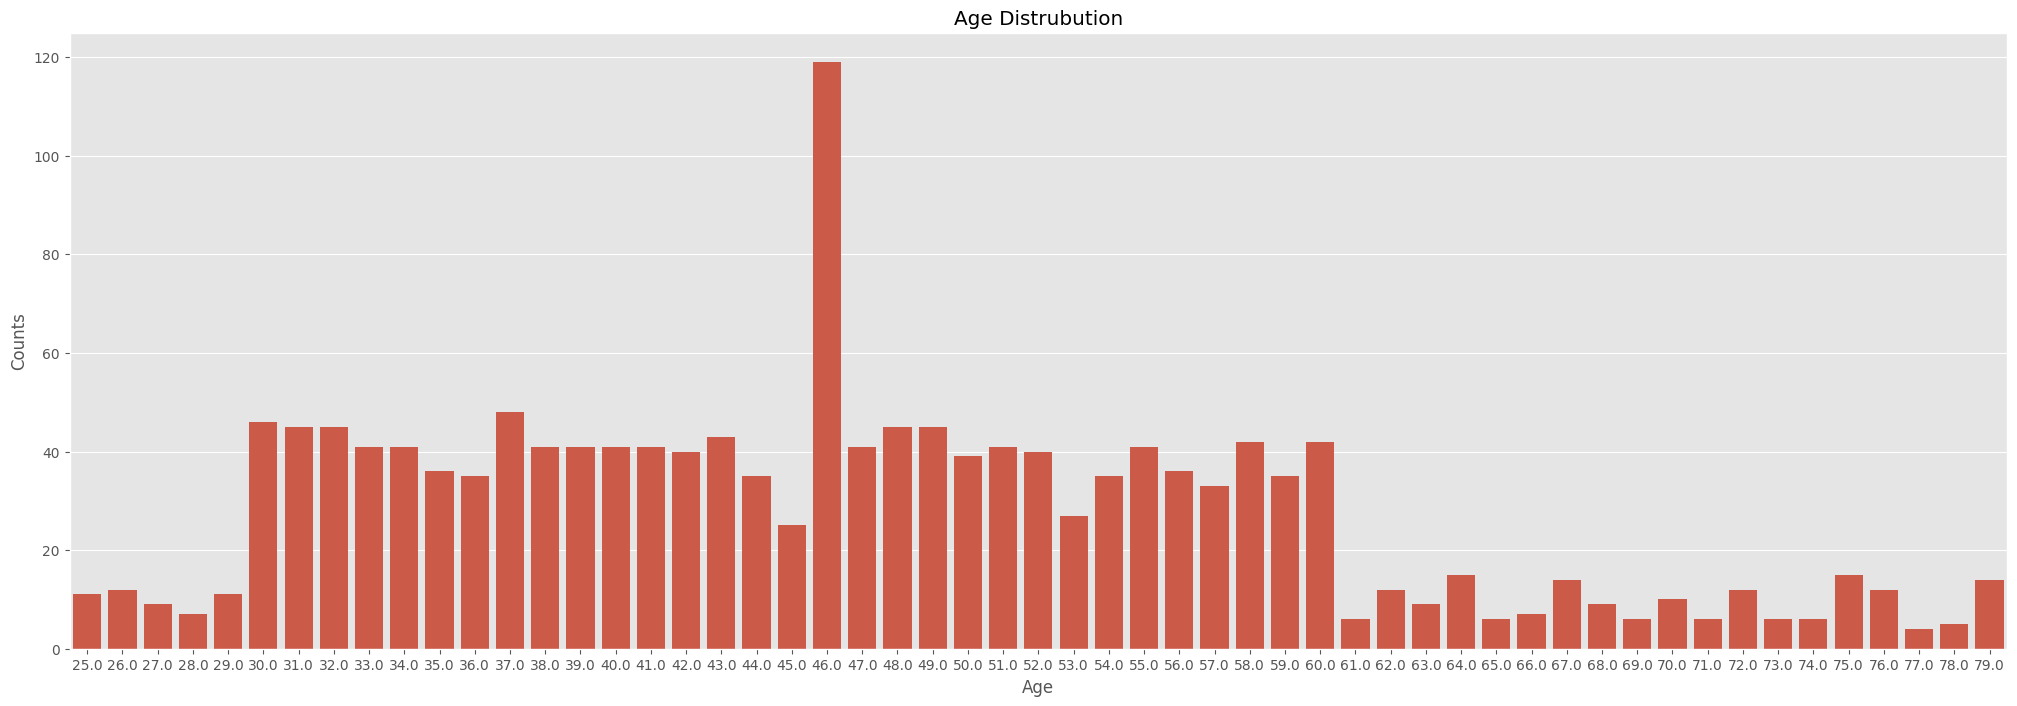

In [35]:
#Age
fig, ax = plt.subplots(figsize=(25,8))
age_dis=pd.DataFrame(df.groupby(['Age'])['index'].count())
sns.barplot(x=age_dis.index,y=age_dis['index'])
plt.ylabel('Counts')
plt.title('Age Distrubution')

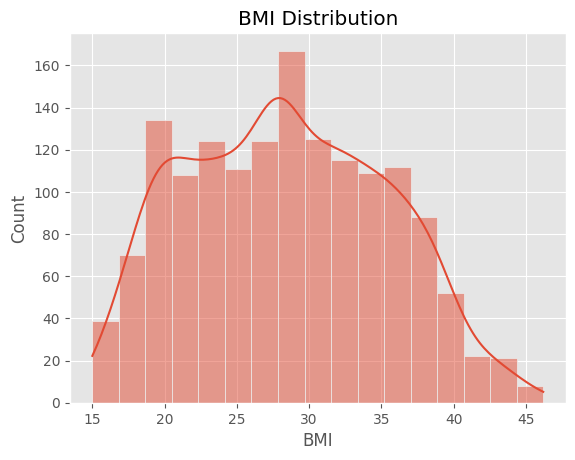

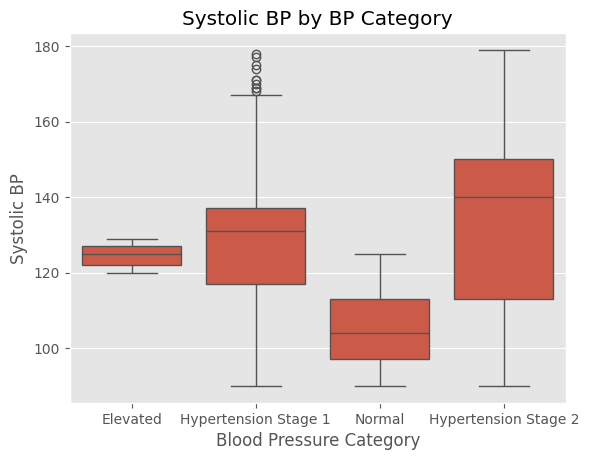

In [36]:
#BMI and blood pressure focus
sns.histplot(df["BMI"], kde=True)
plt.title("BMI Distribution")
plt.show()

sns.boxplot(x=df["Blood Pressure Category"], y=df["Systolic BP"])
plt.title("Systolic BP by BP Category")
plt.show()

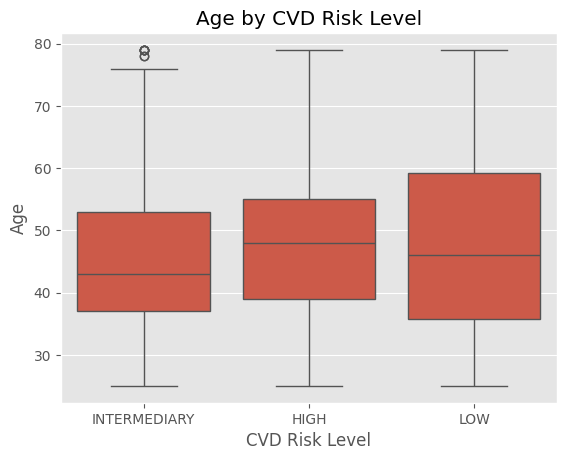

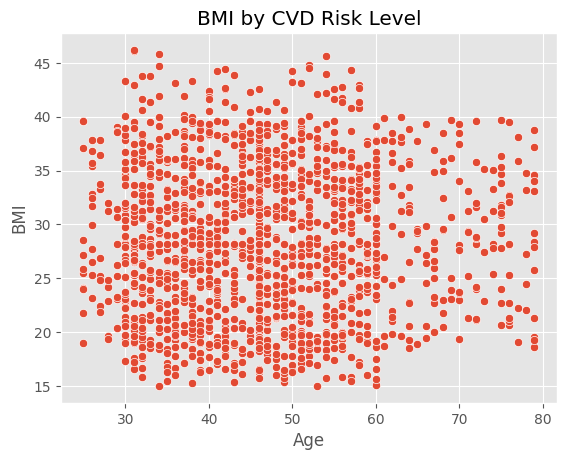

In [40]:
sns.boxplot(x="CVD Risk Level", y="Age", data=df)
plt.title("Age by CVD Risk Level")
plt.show()

sns.scatterplot(x="Age", y="BMI", data=df)
plt.title("BMI by CVD Risk Level")
plt.show()

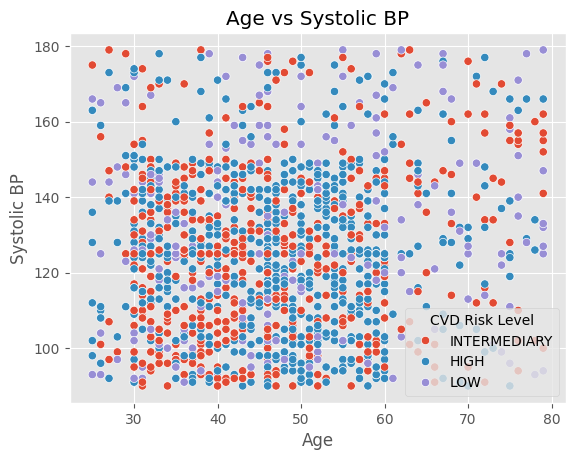

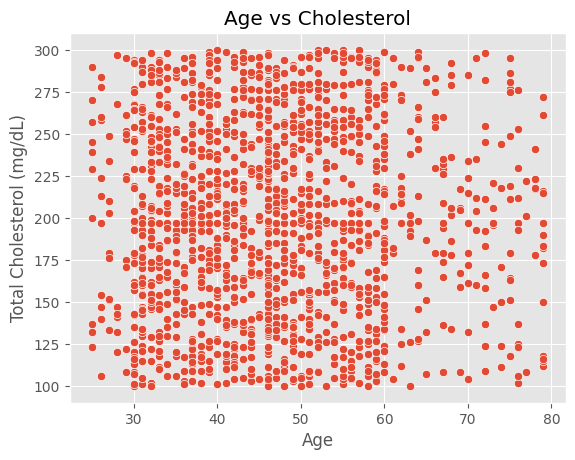

In [41]:
sns.scatterplot(x="Age", y="Systolic BP", hue="CVD Risk Level", data=df)
plt.title("Age vs Systolic BP")
plt.show()

sns.scatterplot(x="Age", y="Total Cholesterol (mg/dL)", data=df)
plt.title("Age vs Cholesterol")
plt.show()
